# TME Composition ISP Analysis Tutorial (Gene Expression Prediction)

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) results for **TME (Tumor Microenvironment) composition** experiments using Gene Expression Prediction (GEP). Unlike rank-based ISP, TME composition ISP simulates changes in the proportion of different TME cell types to study how TME composition affects epithelial cell gene expression.

## Overview

In this tutorial, you will learn how to:
1. Run TME composition ISP simulations
2. Load and analyze TME composition ISP results
3. Calculate Z-scores for each TME cell type perturbation
4. Visualize the results with bar plots

## TME Cell Types

The Xenium dataset contains the following TME cell types: 

| tme_id | Cell Type |
|--------|-----------|
| 1 | Epithelia |
| 2 | T_lymph |
| 3 | Monocyte |
| 5 | Fibroblast |
| 6 | Endothelial |
| 7 | B_lymph |
| 8 | Mast |

## Marker Gene Set (SET1)

The SET1 marker genes used in this analysis are: SYP, CHGA, ENO2, NCAM1


## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Have a trained GEP model
- Run the TME composition ISP simulation script (see below)

### Step 0: Run TME Composition ISP Simulation

First, execute the TME composition ISP simulation script to generate perturbation results:

```bash
# TME Composition ISP: Perturb TME composition for Monocyte (tme_id=3)
tmeformer-gep-isp-tme \
  --device 1 \
  --proj xenium \
  --model_id GF_D1120_06 \
  --marker_set SET1 \
  --tme_method composition --isp_cluster 3 \
  --cell_ratio 10000 \
  --endpoints 2 --window 0.2 \
  --pred_cells internal
```


## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from TMEformer.tme import TmeModeling_utils as tu
from TMEformer.tme import TmeModeling_utils_isp_ds as tu_isp_ds
from TMEformer.tme import TmeModeling_utils_isp_gep as tu_isp_gep
from TMEformer.tme import TmeModeling_utils_isp_sim as tu_isp_sim

/home/liss/miniconda3/envs/geneformer_v3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure working directory and project
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
proj = "xenium"
isp_type = "tme_composition"
pred_cells = "internal"

In [3]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + f"data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

# Compute patch IDs at sample level
patch_size = 500
obsmeta = obsmeta.groupby("sample_id", group_keys=False).apply(
    tu.compute_patch_ids,
    patch_size=patch_size,
    include_groups=False
)

# Create TME ID to cell type mapping
celltype_dict = obsmeta[["tme_id", "cell_type"]].drop_duplicates().set_index("tme_id").sort_index()["cell_type"].to_dict()
print("TME ID to Cell Type Mapping:", celltype_dict)

TME ID to Cell Type Mapping: {1: 'Epithelia', 2: 'T_lymph', 3: 'Monocyte', 5: 'Fibroblast', 6: 'Endothelial', 7: 'B_lymph', 8: 'Mast'}


In [4]:
# Load marker gene set
with open(work_dir + "isp_gene_exp/MODEL_FT_GENE_SET.json", "r") as f:
    FT_Multi_SETs = json.load(f)

set_id = "SET1"
model_gene_list = FT_Multi_SETs[set_id]
print(f"Marker genes for {set_id}: {model_gene_list}")

Marker genes for SET1: ['SYP', 'CHGA', 'ENO2', 'NCAM1']


## Step 2: Load and Process ISP Results

Configure the analysis task, select target conditions, and load ISP simulation results.

In [5]:
# Configure model IDs for analysis
model_color_map = {
    '#377eb8': ["GF_D1120_06"],
}
model_color_map = {v: k for k, v_list in model_color_map.items() for v in v_list}
model_ids = list(model_color_map.keys())
print(f"Model IDs: {model_ids}")

Model IDs: ['GF_D1120_06']


In [6]:
# Summarize ISP simulation results
isp_dict, condi_meta = tu_isp_gep.summary_isp_gep_stat_files(
    task_dir=work_dir + f"isp_gene_exp/{proj}/output_isp/",
    set_id=set_id,
    isp_type=isp_type,
    pred_cells=pred_cells,
    model_ids=model_ids
)

print(f"Found {len(condi_meta)} conditions")

Found 36 conditions


In [8]:
# Define target conditions (TME composition perturbations for different cell types)
if pred_cells == "internal":
    suffix = ""
else:
    suffix = f"_{pred_cells}"

conditions_dict = {
    "Target": [
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME3_FIXall",  
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME2_FIXall",  
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME5_FIXall",  
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME6_FIXall",  
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME7_FIXall",  
        f"{set_id}{suffix}-TME_Composition-S5000-W0.2_EP2.0_KO0_KI0-TME8_FIXall"   
    ],
    "Background": []
}

print(f"Target conditions: {len(conditions_dict['Target'])}")

Target conditions: 6


In [9]:
# Check model conditions (verify models have ISP results)
from collections import defaultdict

candi_model_ids = set([
    model_id for condi_list in conditions_dict.values() for condi in condi_list
    for model_id in isp_dict[condi]
])
candi_model_ids = sorted(candi_model_ids)

model_condi_counts = defaultdict(list)
for model_id in candi_model_ids:
    model_condi_counts["model_id"].append(model_id)
    for k, conditions in conditions_dict.items():
        model_condi_counts[k].append(
            sum([model_id in isp_dict[condition] for condition in conditions])
        )

pd.DataFrame(model_condi_counts)

,model_id,Target,Background
0,GF_D1120_06,6,0


In [10]:
# Merge ISP results for TME composition
stats_raw = tu_isp_gep.merge_isp_gep_stat_raw(
    proj, conditions_dict, model_ids, add_interval=False,
    tme_isp=True, tme_method="composition", work_dir=work_dir
)

# Map TME IDs to cell type names
stats_raw["isp_cell_type"] = stats_raw["isp_cell_type"].apply(lambda x: celltype_dict.get(x, x))
stats_raw["group"] = stats_raw["group"].apply(lambda x: celltype_dict.get(x, x))

# Merge with metadata to get sample and patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "sample_name", "patch_id"]])
stats_raw = stats_raw[
    ["model_id", "cell_id", "score_type", "score_method", "cell_score", "model_gene",
     "isp_cell_type", "group", "sample_name", "patch_id"]
]

print(f"Loaded {len(stats_raw)} records")
stats_raw.head()

Loaded 240000 records


,model_id,cell_id,score_type,score_method,cell_score,model_gene,isp_cell_type,group,sample_name,patch_id
0,GF_D1120_06,39717,OE,area,-0.000102,SYP,Monocyte,Monocyte,P005,0_42_29
1,GF_D1120_06,39717,OE,endpoint,0.000781,SYP,Monocyte,Monocyte,P005,0_42_29
2,GF_D1120_06,995314,OE,area,-0.000016,SYP,Monocyte,Monocyte,P018,4_40_24
3,GF_D1120_06,995314,OE,endpoint,-0.000077,SYP,Monocyte,Monocyte,P018,4_40_24
4,GF_D1120_06,1180443,OE,area,0.001324,SYP,Monocyte,Monocyte,P020,5_7_35


In [11]:
# Filter and aggregate results at patch level
score_type = "OE"
score_method = "endpoint"
score_interval = "[0, 1]"
stat_level = "patch"
stat_method = "mean"

stats_filt = tu_isp_gep.filter_isp_gep_stat_raw(
    stats_raw, score_type, score_method,
    stat_level=stat_level, stat_method=stat_method, pair=True,
)

print(f"Filtered to {len(stats_filt)} records")
stats_filt.head()

Filtered to 20992 records


,model_id,model_gene,patch_id,score_type,score_method,group,cell_score
0,GF_D1120_06,CHGA,0_38_27,OE,endpoint,B_lymph,0.000018
1,GF_D1120_06,CHGA,0_38_27,OE,endpoint,Endothelial,-0.000059
2,GF_D1120_06,CHGA,0_38_27,OE,endpoint,Fibroblast,0.005728
3,GF_D1120_06,CHGA,0_38_27,OE,endpoint,Monocyte,0.001262
4,GF_D1120_06,CHGA,0_38_28,OE,endpoint,Endothelial,0.001793


## Step 3: Calculate Z-scores

Calculate patch-level Z-scores and aggregate across marker genes to get overall ISP scores for each TME cell type.

In [12]:
# Merge with sample treatment information
stats_filt_sp = stats_filt.merge(
    obsmeta[["sample_name", "treat2", "patch_id"]].drop_duplicates(),
)[["model_gene", "patch_id", "sample_name", "treat2", "group", "cell_score"]]

print(f"Merged data shape: {stats_filt_sp.shape}")

# Calculate patch-level Z-scores
z_score_df = stats_filt_sp.copy()
z_score_df['cell_score_z'] = z_score_df.groupby(["model_gene", "patch_id"])["cell_score"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Calculate mean Z-scores by model gene
group_cols = [col for col in z_score_df.columns if col not in ["cell_score", "model_gene", "cell_score_z"]]
z_score_df_mean = z_score_df.groupby(group_cols)["cell_score_z"].mean().reset_index()
z_score_df_mean["model_gene"] = "Overall"
z_score_df_mean = z_score_df_mean.rename(columns={"cell_score_z": "cell_score"})

# Combine original and overall scores
stats_filt_sp = pd.concat([stats_filt_sp, z_score_df_mean])

print("Model gene distribution:")
print(stats_filt_sp["model_gene"].value_counts())

Merged data shape: (20992, 6)
Model gene distribution:
model_gene
CHGA       5248
ENO2       5248
NCAM1      5248
SYP        5248
Overall    5248
Name: count, dtype: int64


## Step 4: Visualization and Interpretation

Create a bar plot to visualize the mean ISP Z-scores for each TME cell type perturbation.

/tmp/ipykernel_1079065/3424231025.py:6: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#333333'}` instead.

  sns.barplot(
/tmp/ipykernel_1079065/3424231025.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(


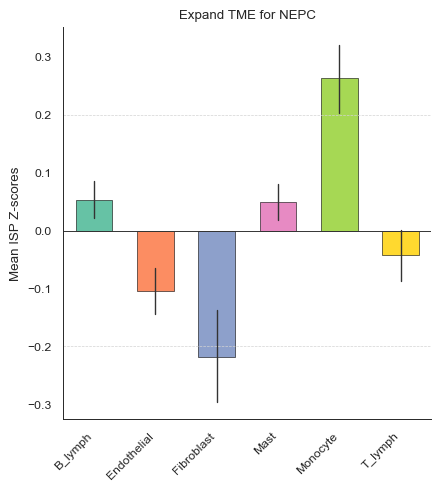

In [13]:
# Create the visualization
sns.set_theme(context='paper', style='white')

plt.figure(figsize=(4.5, 5))

sns.barplot(
    data=stats_filt_sp.query("model_gene=='Overall'").sort_values("group"),
    x="group",
    y="cell_score",
    width=0.6,
    edgecolor="black",
    linewidth=0.4,
    errcolor="#333333",
    errwidth=1,
    hue="group",
    saturation=1,
    palette="Set2",
)

# Add reference lines
plt.axhline(0, color='#333333', linewidth=0.7, linestyle='-')
plt.axhline(0.2, color='lightgrey', linewidth=0.5, linestyle='--')
plt.axhline(-0.2, color='lightgrey', linewidth=0.5, linestyle='--')

# Customize plot
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Mean ISP Z-scores")
plt.title("Expand TME for NEPC")

sns.despine()

# Customize spines
ax = plt.gca()
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)

plt.tight_layout()
plt.show()

## Interpretation

The plot shows the mean ISP Z-scores for each TME cell type perturbation:
- **Positive Z-scores**: Indicate that expanding this cell type increases marker gene expression (promotes NEPC-like state)
- **Negative Z-scores**: Indicate that expanding this cell type decreases marker gene expression
- **Z-scores near 0**: Indicate minimal effect on marker gene expression